# The twin — data ↔ simulation coupling

`oneuniverse.twin` is the coupling layer: data → reconstruct the field → forward-model / resimulate. We show the loop working on the dummy, then the places it breaks.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from oneuniverse.simulation.cosmology import CosmologySpec
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.twin import (mock_tracer_field, wiener_reconstruct,
    constrained_realization, recover_metrics, registered_engines)
from oneuniverse.twin.verify import cross_correlation, power_ratio
C = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
BOX, N = 256.0, 64

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. The mock challenge — recover the field from biased tracers
truth → mock-observe (biased Poisson tracers) → Wiener filter → cross-correlation r(k) vs truth. r→1 at large scales, falling where shot noise dominates.

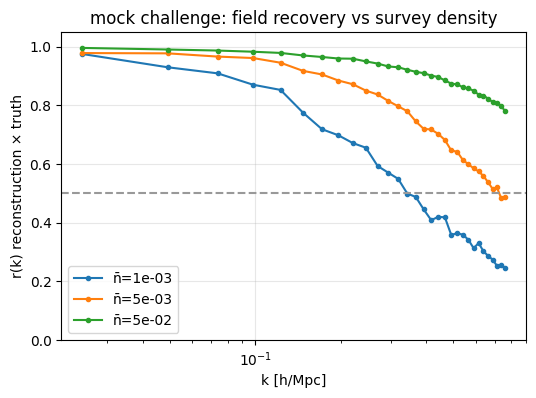

In [2]:
truth = generate_density_field(C, box_size=BOX, n_grid=N, z=0.0, seed=2)
plt.figure(figsize=(6,4))
for nbar in (1e-3, 5e-3, 5e-2):
    obs = mock_tracer_field(truth, box_size=BOX, nbar=nbar, bias=1.5, seed=3)
    rec = wiener_reconstruct(obs['delta_g'], C, box_size=BOX, nbar=nbar, bias=1.5)
    k, r = cross_correlation(rec, truth, box_size=BOX)
    plt.semilogx(k, r, 'o-', ms=3, label=f'n̄={nbar:.0e}')
plt.axhline(0.5, color='.6', ls='--'); plt.ylim(0,1.05)
plt.xlabel('k [h/Mpc]'); plt.ylabel('r(k) reconstruction × truth')
plt.title('mock challenge: field recovery vs survey density'); plt.legend(); plt.grid(alpha=.3); plt.show()

## 2. Wiener mean vs constrained realization
The Wiener mean is power-suppressed at high k; the Hoffman–Ribak constrained realization restores P(k) (clean-linear regime).

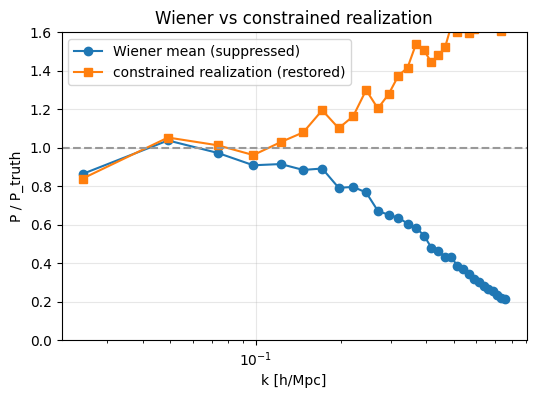

In [3]:
rng = np.random.default_rng(7)
nbar, bias = 1e-3, 1.5
dg = bias*truth + rng.normal(0, 1/np.sqrt(nbar*(BOX/N)**3), (N,N,N))  # clean linear obs
wf = wiener_reconstruct(dg, C, box_size=BOX, nbar=nbar, bias=bias)
cr = constrained_realization(dg, C, box_size=BOX, nbar=nbar, bias=bias, seed=7)
k, rwf = power_ratio(wf, truth, box_size=BOX); _, rcr = power_ratio(cr, truth, box_size=BOX)
plt.figure(figsize=(6,4))
plt.semilogx(k, rwf, 'o-', label='Wiener mean (suppressed)')
plt.semilogx(k, rcr, 's-', label='constrained realization (restored)')
plt.axhline(1, color='.6', ls='--'); plt.ylim(0,1.6)
plt.xlabel('k [h/Mpc]'); plt.ylabel('P / P_truth')
plt.title('Wiener vs constrained realization'); plt.legend(); plt.grid(alpha=.3); plt.show()

## 3. Data-driven dispatch — the orchestration loop
`SimDatabase` turns a region selection into a request and dispatches the resim **from the data-constrained IC** (not a seed).

In [4]:
import tempfile; from pathlib import Path
from oneuniverse.simulation.linear import generate_linear_sim
from oneuniverse.simulation.oufsim import write_oufsim_store
from oneuniverse.simulation.oufsim.database import SimDatabase
W = Path(tempfile.mkdtemp())
nat = generate_linear_sim(W/'n', C, box_size=BOX, n_grid=N, redshifts=(0.0,), seed=2)
write_oufsim_store(nat, W/'root', sim_name='box')
db = SimDatabase(W/'root').scan()
req = db.request_region('box', target_lo=96.0, target_side=64.0, buffer=37.5,
                        ic_strategy='constrained_from_posterior')
inner, child = db.dispatch(req, ic_field=cr, n_steps=12)
print('dispatched child:', child)
print('lineage edge:', db.lineage[0])
print('request status:', db.requests[0].status)

dispatched child: box_zoom
lineage edge: {'parent': 'box', 'child': 'box_zoom', 'region': 'box_region', 'ic_source': 'constrained_from_posterior', 'valid_time': '2026-06-03T13:42:40.352878+00:00'}
request status: ingested


## 4. Engine contracts (generality)
Reconstruction + forward engines satisfy a common contract; a real code plugs in over the same store boundary.

In [5]:
print('registered engines:', registered_engines())

registered engines: ('fastpm', 'linear', 'wiener')


## ⚠️ What is NOT working

### (a) Linear-bias Poisson mock breaks for non-linear fields
`mock_tracer_field` clips `1+bδ` at 0; once σ_cell ≳ 1 this biases the *effective* tracer bias low (b=1.5 requested samples as ~0.6). Fine for correlation r(k); **wrong for absolute-power** work. A lognormal/HOD mock is the proper fix (future).

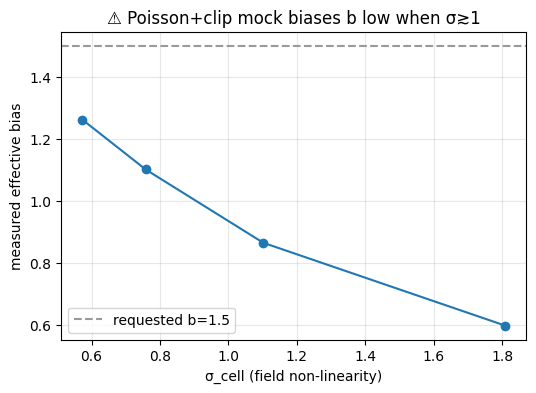

σ_cell: [1.81 1.1  0.76 0.57]  b_eff: [0.6  0.86 1.1  1.26]


In [6]:
def b_eff(z):
    t = generate_density_field(C, box_size=BOX, n_grid=N, z=z, seed=2)
    dg = mock_tracer_field(t, box_size=BOX, nbar=5e-2, bias=1.5, seed=3)['delta_g']
    fk = np.fft.rfftn(dg); tk = np.fft.rfftn(t)
    from oneuniverse.twin.verify import _bin_kgrid, _bins
    km = _bin_kgrid(N, BOX); idx, edges, ctr = _bins(km, BOX, N)
    pd = (np.abs(fk)**2).ravel(); pt = (np.abs(tk)**2).ravel()
    rs = [pd[idx==i].sum()/pt[idx==i].sum() for i in range(1,6) if (idx==i).sum()]
    return float(t.std()), float(np.sqrt(np.median(rs)))
sig, be = zip(*[b_eff(z) for z in (0.0,1.0,2.0,3.0)])
plt.figure(figsize=(6,4)); plt.plot(sig, be, 'o-')
plt.axhline(1.5, color='.6', ls='--', label='requested b=1.5')
plt.xlabel('σ_cell (field non-linearity)'); plt.ylabel('measured effective bias')
plt.title('⚠️ Poisson+clip mock biases b low when σ≳1'); plt.legend(); plt.grid(alpha=.3); plt.show()
print('σ_cell:', np.round(sig,2), ' b_eff:', np.round(be,2))

### (b) Constrained realization: right power, random small-scale phases
The CR matches P(k) everywhere but its *small-scale phases* are a new random draw (it is a realization, not the truth) — so r(k) drops at high k even though the power is correct. Below: r(k) (phases) vs P/P_truth (power) for the CR.

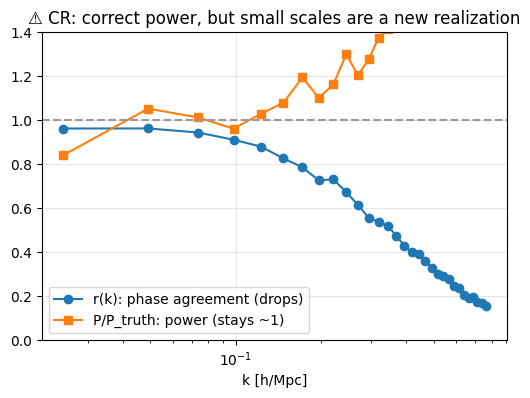

In [7]:
k, rxc = cross_correlation(cr, truth, box_size=BOX); _, prc = power_ratio(cr, truth, box_size=BOX)
plt.figure(figsize=(6,4))
plt.semilogx(k, rxc, 'o-', label='r(k): phase agreement (drops)')
plt.semilogx(k, prc, 's-', label='P/P_truth: power (stays ~1)')
plt.axhline(1, color='.6', ls='--'); plt.ylim(0,1.4)
plt.xlabel('k [h/Mpc]')
plt.title('⚠️ CR: correct power, but small scales are a new realization')
plt.legend(); plt.grid(alpha=.3); plt.show()

### (c) Other open gaps
- **SBI** deferred to future (ensemble mode exists; the inference does not).
- **Multi-physics** (hydro/baryons) generation: DM-only.
- **sCOLA buffer coupling** (smaller buffers / bounded-memory resim): broken — see notebook 05 §(a).